In [1]:
#This is a clean document trying to break down the density calculation, does it make sense? 
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D
from scipy import stats
from scipy.optimize import minimize
from sklearn.utils import resample

plt.rcParams.update({
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10
})

print('Imports successful')

Imports successful



## Simple approach to  the density model

If we just use the mean values of the parameters (cT, cW, cR, cH, Tc), reported in Winterl et al. 2024 and plug them in the windchill formula:

rho_pred = rho_max/(1 + exp( cT*T + cW*W + cH*H + cR*R - Tc ))  

with:
rho_max = 12.83 1/m²
T : temperature in K, W: windspeed in m/s, H: relative humidity in %, R: solar radiation in W/m²

Then use rho_pred and area A to predict the number of individuals

count_pred = rho_pred * A



###  Supplementary Table 3 (Winterl et al. 2024)
The table contains the numerical values for the best estimate of the windchill model
parameters.  

|      |   cT     |    cW     |     cR       |     cH    |       Tc     |      sigma |
|------|----------|-----------|--------------|-----------|--------------|------------| 
| mean |-0.023845 | 0.079986  | -0.000767    | 0.008434  |   -4.903825  |    0.731349| 
| std  | 0.003476 |  0.007152 |   0.000133   | 0.001784  |    0.909726  |    0.023509|


In [ ]:
#Original 
cT = -0.023845
cW = 0.079986 
cR = -0.000767 
cH = 0.008434 
Tc = -4.903825 
sigma = 0.731349
rho_max = 12.83

# Posterior SDs from convergence diagnostics table
sd_T  = 0.003476
sd_W  = 0.007152
sd_R  = 0.000133
sd_H  = 0.001784
sd_Tc = 0.909726

# One example from Amanda Bay - first row of the dfRFD csv file AMAN 139
# Windspeed         Temperature (K)     Humidity            Radiation
#3.380879163742065	247.7754821777344	74.00595786344412	0

T = 247.7754821777344
W = 3.380879163742065
H = 74.00595786344412
R = 0

#From there I will edit the values to see if we can determine whether the weather has the ecologically correct effect - change winds and temperatures to see how it changes rho 

In [ ]:
# I am going to simplify the weather variables, see if we can re do the analysis that I did manually on the powerpoint 


#Plug them in the windchill formula
#rho_pred = rho_max/(1 + exp( cT*T + cW*W + cH*H + cR*R - Tc ))

#with:
#rho_max = 12.83 1/m²
#T : temperature in K, W: windspeed in m/s, H: relative humidity in %, R: solar radiation in W/m²

#Then use rho_pred and area A to predict the number of individuals:
#count_pred = rho_pred * A


rho_pred_orig = rho_max/(1 + np.exp( (cT*T) + (cW*W) + (cH*H) + (cR*R) - Tc ))
print(rho_pred_orig)

6.766804908747927


In [9]:
rho_pred_paren = rho_max/(1 + np.exp( (cT*T) + (cW*W) + (cH*H) + (cR*R) - Tc ))
print(rho_pred_paren)

6.766804908747927


In [ ]:
# One example from Amanda Bay - first row of the dfRFD csv file 
# Windspeed         Temperature (K)     Humidity            Radiation
#3.380879163742065	247.7754821777344	74.00595786344412	0

T2 = 267.7754821777344 #added 20 degrees Kelvin
W = 3.380879163742065
H = 74.00595786344412
R = 0

#From there I will edit the values to see if we can determine whether the weather has the ecologically correct effect - change winds and temperatures to see how it changes rho 

In [13]:
rho_pred_20K = rho_max/(1 + np.exp( cT*T2 + cW*W + cH*H + cR*R - Tc ))
print(rho_pred_20K)

#I tested both parenthese and non parentheses and these make no difference. 

8.244632487432312


## This shows that when temperature increases, density increases. Which is not what we want, that does not make sense. 

In [ ]:
#Let's check windspeed too 
# One example from Amanda Bay - first row of the dfRFD csv file 
# Windspeed         Temperature (K)     Humidity            Radiation
#3.380879163742065	247.7754821777344	74.00595786344412	0

T = 247.7754821777344
W2 = 8.380879163742065 #changed from 3 to 8
H = 74.00595786344412
R = 0


rho_pred_8W = rho_max/(1 + np.exp( cT*T + cW*W2 + cH*H + cR*R - Tc ))
print(rho_pred_8W)

5.490856547990797


### This one here shows again, increase in windspeed decreases density 

Next up, is to break the equation down piece by piece. 

First we will do each individual part of the exponent, then we will do it step by step.

In [21]:
#rho_pred = rho_max/(1 + np.exp( cT*T + cW*W + cH*H + cR*R - Tc ))

print(cT*T)
print(cW*W)
print(cR*R)
print(cH*H)
print(Tc)

-5.908206372528078
0.27042300079107284
-0.0
0.6241662486202878
-4.903825


## Ok next up the exponent: 

The exponential function is e^x where e is a mathematical constant called Euler's number, approximately 2.718281. This value has a close mathematical relationship with pi and the slope of the curve e^x is equal to its value at every point. np.exp() calculates e^x for each value of x in your input array.

In [22]:
#rho_pred = rho_max/(1 + np.exp( cT*T + cW*W + cH*H + cR*R - Tc ))

np.exp(-5.908206372528078 + 0.27042300079107284 + 0.0 + 0.6241662486202878 + 4.903825)

np.float64(0.8960203778616039)

In [23]:
#rho_pred = rho_max/(1 + np.exp( cT*T + cW*W + cH*H + cR*R - Tc ))

1 + 0.8960203778616039

1.8960203778616038

In [ ]:
12.83/1.8960203778616038
#This matches with the full equation approach outlined above, indicating it is not a formatting error but appears to be a fundamental error with how the model is treating weather variables in relation to density

6.766804908747927

### Each part of this seems to be working, except for the affect of increasing temperature and decreasing density

## Ok next up, Michelle has suggested to try to calculate Ta_C first, convert temperature to celcius and then run the density equation again with that rather than the raw weather values 


In [50]:
#Original 
cT = -0.023845
cW = 0.079986 
cR = -0.000767 
cH = 0.008434 
Tc = -4.903825 
sigma = 0.731349
rho_max = 12.83

# Posterior SDs from convergence diagnostics table
sd_T  = 0.003476
sd_W  = 0.007152
sd_R  = 0.000133
sd_H  = 0.001784
sd_Tc = 0.909726

# One example from Amanda Bay - first row of the dfRFD csv file AMAN 139
# Windspeed         Temperature (K)     Humidity            Radiation
#3.380879163742065	247.7754821777344	74.00595786344412	0

T = 247.7754821777344
W = 3.380879163742065
H = 74.00595786344412
R = 0



In [51]:
#Within the Winterl Phenology model code, it says: 
#pm.Deterministic("Ta_C", t_temp + (model.cW * t_wind + model.cR * t_rad + model.cH * t_humc)/model.cT - 273.15),

#We translated that into this:

# Apparent temperature — point estimate
Ta_C = T + ((cW * W) + (cR * R) + (cH * H)) / cT - 273.15 #the apparent temperature in celsius 
print(Ta_C)

-62.89136619346962


In [52]:
rho_pred_TaC = rho_max/(1 + np.exp((Ta_C - Tc)))
print(rho_pred_TaC)
#Whyyyyy this that equal to rho_max????

12.83


## It has also been suggested to try adding a negative sign to the e symbol at the bottom

Let's see how we go.

In [38]:
rho_pred_TaC_neg = rho_max/(1 + 2.71828^(-(Ta_C - Tc) )) #figure out where/how to make exponent negtaive
print(rho_pred_TaC_neg)

#no change

TypeError: unsupported operand type(s) for ^: 'float' and 'float'

## Ok now trying to add the b0 constant which was included in his reported equation but not in the one he shared with me 

In [53]:
b0 = 1/-0.023845 #-1/cT

print(b0)

-41.937513105472846


In [54]:
rho_pred_TaC_b0 = rho_max/(1 + np.exp((Ta_C - Tc)/b0))
print(rho_pred_TaC_b0)

2.5733598826566273


In [47]:
rho_pred_TaC_b0 = rho_max/(1 + np.exp(-(Ta_C- Tc)/b0)) #we do need a negative on the exponent and the b0 is also important
print(rho_pred_TaC_b0)

#Ok so change to a negative makes it a negative number, which is not allowed as we can't have negative density 

10.256640117343371


## But the one where I added in b0 could possibly be OK. 
Let's see what happens when I change temperature - does it increase or decrease density? 

Also, let's check if TaC needs to be calculated first, do they both produce the same answers?

In [55]:
rho_pred_TaC_b0 = rho_max/(1 + np.exp(-(Ta_C - Tc)/b0))
print(rho_pred_TaC_b0)


rho_pred_noTaC = rho_max/(1 + np.exp(-(cT*T + cW*W + cH*H + cR*R - Tc)/b0 ))
print(rho_pred_noTaC)

10.256640117343371
6.423397208314989


## Not the same answer at all. 
So now what happens when I increase temperature for both of them

In [56]:
#Modifying this Amanda data to see if it results in what we would expect ecologically - decreased density with higher temps 
# One example from Amanda Bay - first row of the dfRFD csv file AMAN 139
# Windspeed         Temperature (K)     Humidity            Radiation
#3.380879163742065	247.7754821777344	74.00595786344412	0

T2 = 267.7754821777344 #increased 20K
W = 3.380879163742065
H = 74.00595786344412
R = 0

# Apparent temperature — point estimate
Ta_C2 = T2 + ((cW * W) + (cR * R) + (cH * H)) / cT - 273.15 #the apparent temperature in celsius 
print(Ta_C2)

-42.89136619346965


In [58]:
rho_pred_TaC2_b0 = rho_max/(1 + np.exp(-(Ta_C2 - Tc)/b0))
print(rho_pred_TaC2_b0)


rho_pred_noTaC2 = rho_max/(1 + np.exp(- (cT*T2 + cW*W + cH*H + cR*R - Tc)/b0 ))
print(rho_pred_noTaC2)

9.136789468909017
6.45987114650262


## Ok so we have figure out that it may just be a missing negative value between the np.exp(-(cT*T + xxyyy))

If that is the solution I will be relieved by also slightly annoyed its taken a million years to figure it out. 

In [59]:
rho_pred_neg = rho_max/(1 + np.exp(-(cT*T + cW*W + cH*H + cR*R - Tc))) #/b0 
print(rho_pred_neg)

rho_pred_neg2 = rho_max/(1 + np.exp(-(cT*T2 + cW*W + cH*H + cR*R - Tc))) #/b0 
print(rho_pred_neg2)


6.063195091252074
4.585367512567688


## Higher temperature = lower density! 

In [61]:
## Ok and now do the values match when we remove the cT term and add /b0 

rho_pred_b0 = rho_max/(1 + np.exp(-((T + cW*W + cH*H + cR*R - Tc)/b0 ))) #
print(rho_pred_b0)

rho_pred_b02 = rho_max/(1 + np.exp(-((T2 + cW*W + cH*H + cR*R - Tc)/b0))) # 
print(rho_pred_b02)

#Ok so that doesn't work

0.03028669452069084
0.01881593774263454


In [62]:
#Ok now do I try it for the rest of them?? 

INPUTPATH = "/mnt/c/Users/rfo37/OneDrive - University of Canterbury/PostDoc/Population modelling/"

dfRFD = pd.read_excel(
    os.path.join(INPUTPATH, "SAR_datav2_ERA5_v7_cleaned.xlsx")
).drop(columns="Unnamed: 0")

dfMLR = pd.read_excel(
    os.path.join(INPUTPATH, "sar_huddles20230502_ERA5_grouped_v4.xlsx"))# "sar_huddles_20250502_ERA5_v3_grouped.xlsx")
#).drop(columns="Unnamed: 0")

In [63]:
#Weather data from Michelle's 2024 data
T = dfMLR["temp_airK"].values
W = dfMLR["met_ff10"].values
R = dfMLR["met_rad"].values
H = dfMLR["met_humc"].values

In [64]:
rho_pred = rho_max/(1 + np.exp(-((cT*T) + (cW*W) + (cH*H) + (cR*R) - Tc))) #test both removing b0 and removing cT term and see if they produce the same results, needs to be negative. make plots

In [67]:
#And now we take that rho pred and mutliply it by area to get our count estimates

area_m2 = dfMLR["area_m2"].values

count_pred = rho_pred * area_m2

# Add to dataframe
dfMLR["rho_pred"] = rho_pred
dfMLR["count_pred"] = count_pred

#Does the relationship make sense in terms of apparent temperature
Ta_C = T + ((cW * W) + (cR * R) + (cH * H)) / cT - 273.15 #the apparent temperature in celsius 

dfMLR["Ta_C"] = Ta_C


print(dfMLR[["colony", "date", "rho_pred", "count_pred", "Ta_C"]].dropna().head(10).round(2))
print(f"\nrho_pred range:")
print(f"  Min:    {dfMLR['rho_pred'].min():.4f}")
print(f"  Max:    {dfMLR['rho_pred'].max():.4f}")
print(f"  Mean:   {dfMLR['rho_pred'].mean():.4f}")
print(f"  Median: {dfMLR['rho_pred'].median():.4f}")
print(f"  Range:  {dfMLR['rho_pred'].max() - dfMLR['rho_pred'].min():.4f}")

      colony       date  rho_pred  count_pred   Ta_C
1   Atka Bay 2024-04-12      8.53    13308.62 -96.22
2   Atka Bay 2024-04-24      7.79    19879.09 -85.76
3   Atka Bay 2024-04-29      6.69     4947.58 -71.06
4   Atka Bay 2024-05-09      6.07    19863.07 -62.96
5   Atka Bay 2024-05-24      6.35    13191.72 -66.59
6   Atka Bay 2024-06-07      6.49    14606.38 -68.49
7   Atka Bay 2024-06-19      6.73     9093.79 -71.65
8   Atka Bay 2024-06-25      6.19     7373.74 -64.57
9   Atka Bay 2024-07-12      7.55     8002.92 -82.48
10  Atka Bay 2024-08-07      6.50     7393.14 -68.62

rho_pred range:
  Min:    5.0404
  Max:    8.5302
  Mean:   6.5924
  Median: 6.5559
  Range:  3.4897


/tmp/ipykernel_47778/3219067611.py:17: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(dfMLR[["colony", "date", "rho_pred", "count_pred", "Ta_C"]].dropna().head(10).round(2))


# Wow 

#### We figured it out. One tiny missing negative sign! Relief! Now to rerun all the analyses and see how that impacts our conclusions. 

### Onwards!

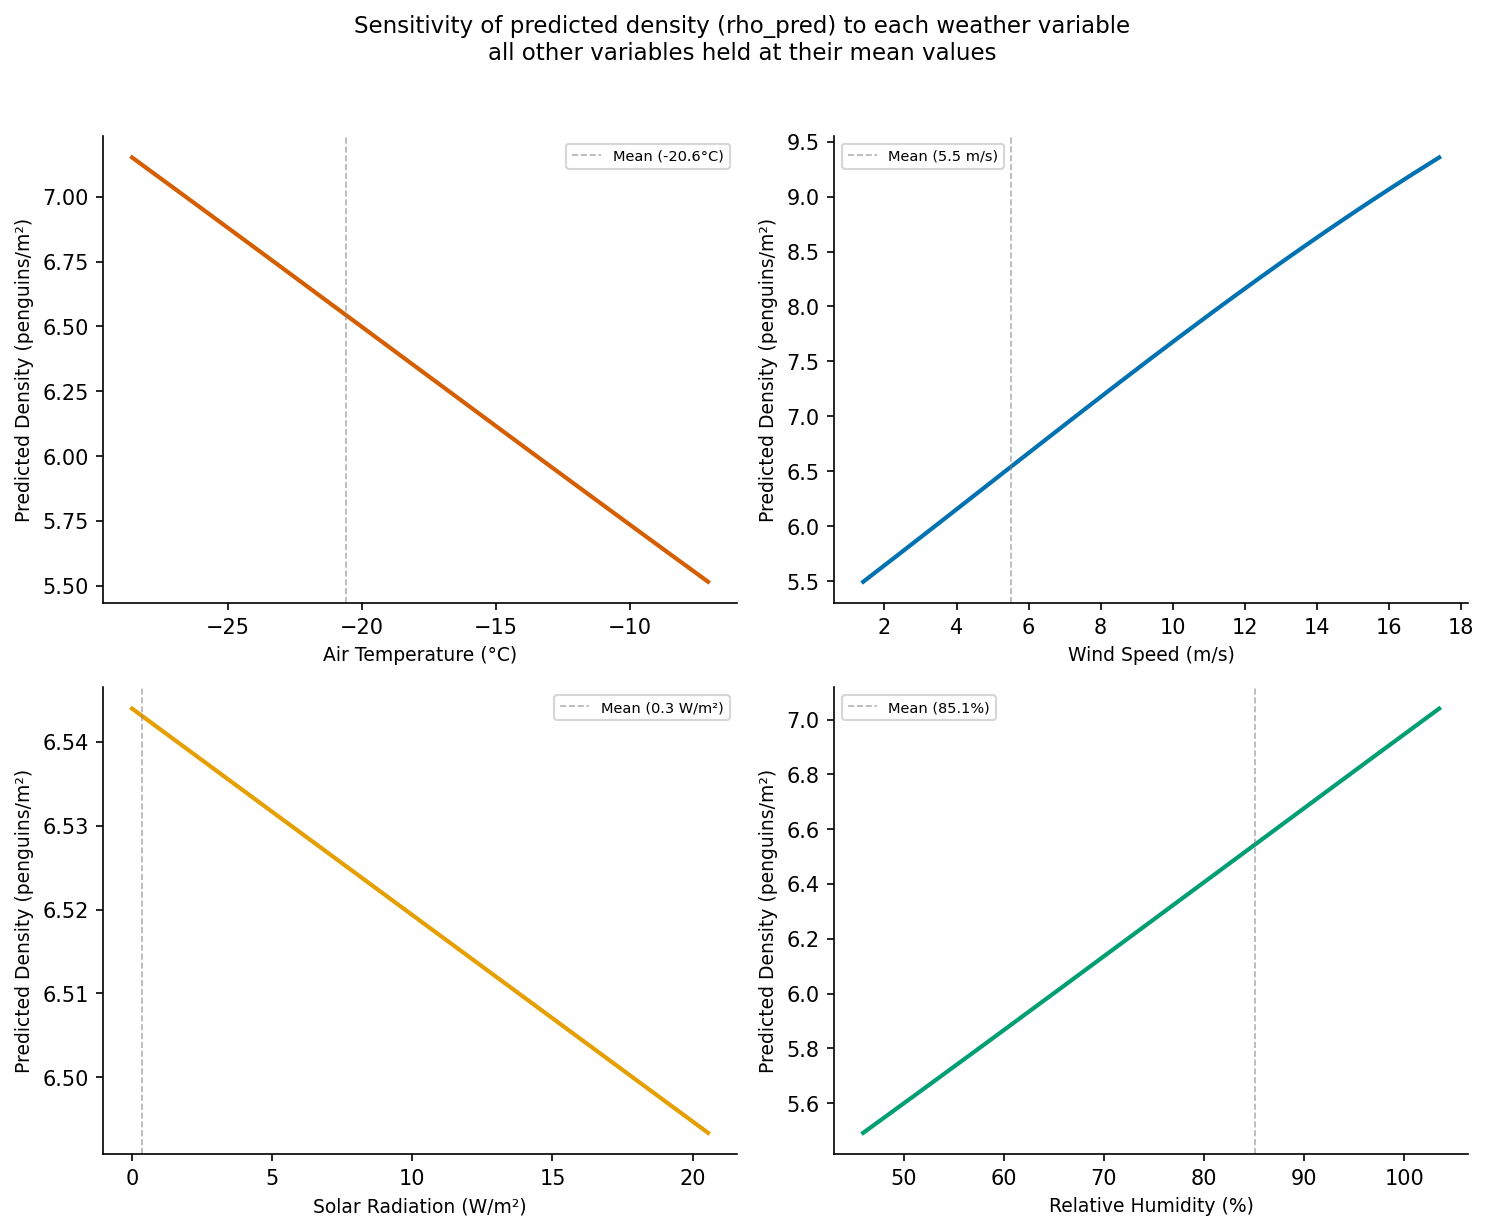

In [73]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Use mean values for all variables except the one being varied
T_mean = dfMLR["temp_airK"].mean()
W_mean = dfMLR["met_ff10"].mean()
R_mean = dfMLR["met_rad"].mean()
H_mean = dfMLR["met_humc"].mean()

# ── Temperature ────────────────────────────────────────────────────────────
ax = axes[0, 0]
T_range = np.linspace(dfMLR["temp_airK"].min(), dfMLR["temp_airK"].max(), 200)
rho_T   = rho_max / (1 + np.exp(-((cT*T_range) + (cW*W_mean) + (cH*H_mean) + (cR*R_mean) - Tc)))
ax.plot(T_range - 273.15, rho_T, color="#D55E00", linewidth=2)
ax.axvline(T_mean - 273.15, color="grey", linewidth=0.8, linestyle="--", alpha=0.6, label=f"Mean ({T_mean-273.15:.1f}°C)")
ax.set_xlabel("Air Temperature (°C)", fontsize=9)
ax.set_ylabel("Predicted Density (penguins/m²)", fontsize=9)
#ax.set_title("rho_pred vs Temperature", fontsize=9)
ax.legend(fontsize=7)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ── Wind speed ─────────────────────────────────────────────────────────────
ax = axes[0, 1]
W_range = np.linspace(dfMLR["met_ff10"].min(), dfMLR["met_ff10"].max(), 200)
rho_W   = rho_max / (1 + np.exp(-((cT*T_mean) + (cW*W_range) + (cH*H_mean) + (cR*R_mean) - Tc)))
ax.plot(W_range, rho_W, color="#0072B2", linewidth=2)
ax.axvline(W_mean, color="grey", linewidth=0.8, linestyle="--", alpha=0.6, label=f"Mean ({W_mean:.1f} m/s)")
ax.set_xlabel("Wind Speed (m/s)", fontsize=9)
ax.set_ylabel("Predicted Density (penguins/m²)", fontsize=9)
#ax.set_title("rho_pred vs Wind Speed", fontsize=9)
ax.legend(fontsize=7)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ── Solar radiation ────────────────────────────────────────────────────────
ax = axes[1, 0]
R_range = np.linspace(dfMLR["met_rad"].min(), dfMLR["met_rad"].max(), 200)
rho_R   = rho_max / (1 + np.exp(-((cT*T_mean) + (cW*W_mean) + (cH*H_mean) + (cR*R_range) - Tc)))
ax.plot(R_range, rho_R, color="#E69F00", linewidth=2)
ax.axvline(R_mean, color="grey", linewidth=0.8, linestyle="--", alpha=0.6, label=f"Mean ({R_mean:.1f} W/m²)")
ax.set_xlabel("Solar Radiation (W/m²)", fontsize=9)
ax.set_ylabel("Predicted Density (penguins/m²)", fontsize=9)
#ax.set_title("rho_pred vs Solar Radiation", fontsize=9)
ax.legend(fontsize=7)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ── Humidity ───────────────────────────────────────────────────────────────
ax = axes[1, 1]
H_range = np.linspace(dfMLR["met_humc"].min(), dfMLR["met_humc"].max(), 200)
rho_H   = rho_max / (1 + np.exp(-((cT*T_mean) + (cW*W_mean) + (cH*H_range) + (cR*R_mean) - Tc)))
ax.plot(H_range, rho_H, color="#009E73", linewidth=2)
ax.axvline(H_mean, color="grey", linewidth=0.8, linestyle="--", alpha=0.6, label=f"Mean ({H_mean:.1f}%)")
ax.set_xlabel("Relative Humidity (%)", fontsize=9)
ax.set_ylabel("Predicted Density (penguins/m²)", fontsize=9)
#ax.set_title("rho_pred vs Humidity", fontsize=9)
ax.legend(fontsize=7)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.suptitle(
    "Sensitivity of predicted density (rho_pred) to each weather variable\n"
    "all other variables held at their mean values",
    fontsize=11, y=1.02
)

plt.tight_layout()
plt.savefig(os.path.join(INPUTPATH,
            "Final results/fig_rho_sensitivity.png"),
            bbox_inches="tight", dpi=200)
plt.show()

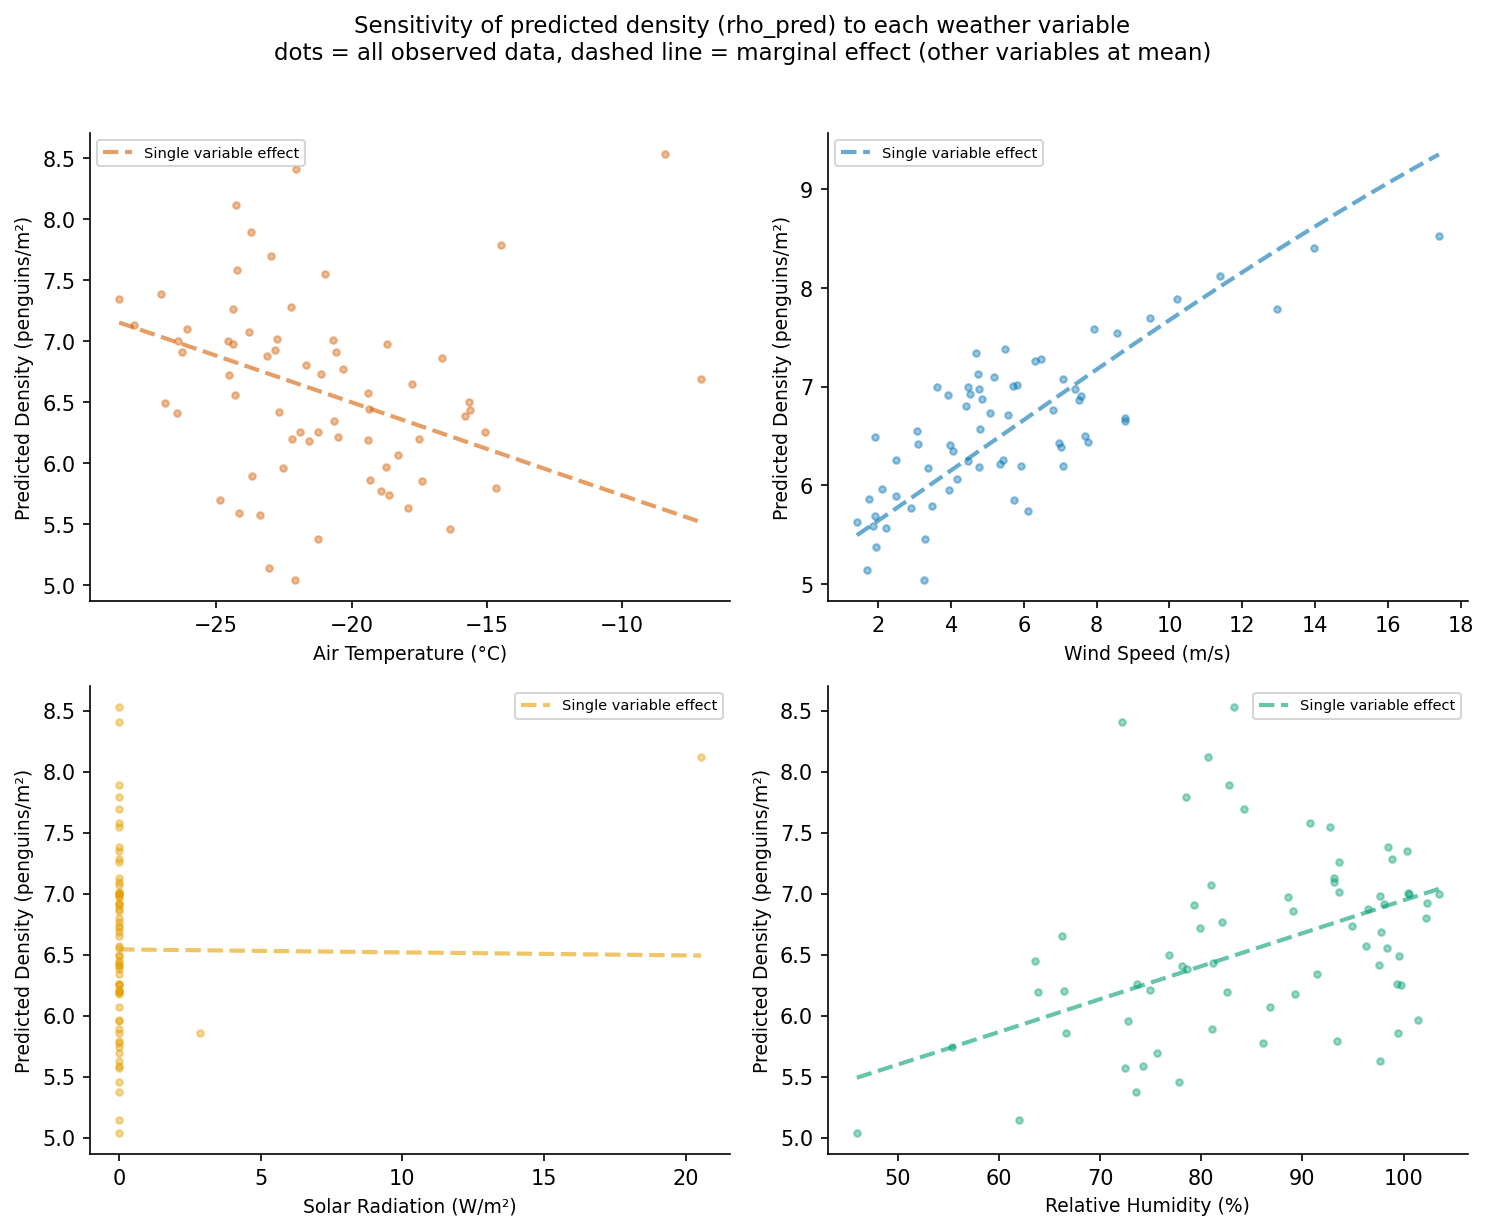

In [74]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# ── Temperature ────────────────────────────────────────────────────────────
ax = axes[0, 0]
# All observed data points
rho_obs_T = rho_max / (1 + np.exp(-((cT * dfMLR["temp_airK"]) +
                                      (cW * dfMLR["met_ff10"]) +
                                      (cH * dfMLR["met_humc"]) +
                                      (cR * dfMLR["met_rad"]) - Tc)))
ax.scatter(dfMLR["temp_airK"] - 273.15, rho_obs_T,
           s=10, alpha=0.4, color="#D55E00", zorder=3)

# Smooth curve across temperature range holding others at mean
T_range = np.linspace(dfMLR["temp_airK"].min(), dfMLR["temp_airK"].max(), 200)
rho_T   = rho_max / (1 + np.exp(-((cT * T_range) +
                                    (cW * W_mean) +
                                    (cH * H_mean) +
                                    (cR * R_mean) - Tc)))
ax.plot(T_range - 273.15, rho_T, color="#D55E00",
        linewidth=2, linestyle="--", alpha=0.6, label="Single variable effect")

ax.set_xlabel("Air Temperature (°C)", fontsize=9)
ax.set_ylabel("Predicted Density (penguins/m²)", fontsize=9)
#ax.set_title("rho_pred vs Temperature", fontsize=9)
ax.legend(fontsize=7)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ── Wind speed ─────────────────────────────────────────────────────────────
ax = axes[0, 1]
ax.scatter(dfMLR["met_ff10"], rho_obs_T,
           s=10, alpha=0.4, color="#0072B2", zorder=3)

W_range = np.linspace(dfMLR["met_ff10"].min(), dfMLR["met_ff10"].max(), 200)
rho_W   = rho_max / (1 + np.exp(-((cT * T_mean) +
                                    (cW * W_range) +
                                    (cH * H_mean) +
                                    (cR * R_mean) - Tc)))
ax.plot(W_range, rho_W, color="#0072B2",
        linewidth=2, linestyle="--", alpha=0.6, label="Single variable effect")

ax.set_xlabel("Wind Speed (m/s)", fontsize=9)
ax.set_ylabel("Predicted Density (penguins/m²)", fontsize=9)
#ax.set_title("rho_pred vs Wind Speed", fontsize=9)
ax.legend(fontsize=7)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ── Solar radiation ────────────────────────────────────────────────────────
ax = axes[1, 0]
ax.scatter(dfMLR["met_rad"], rho_obs_T,
           s=10, alpha=0.4, color="#E69F00", zorder=3)

R_range = np.linspace(dfMLR["met_rad"].min(), dfMLR["met_rad"].max(), 200)
rho_R   = rho_max / (1 + np.exp(-((cT * T_mean) +
                                    (cW * W_mean) +
                                    (cH * H_mean) +
                                    (cR * R_range) - Tc)))
ax.plot(R_range, rho_R, color="#E69F00",
        linewidth=2, linestyle="--", alpha=0.6, label="Single variable effect")

ax.set_xlabel("Solar Radiation (W/m²)", fontsize=9)
ax.set_ylabel("Predicted Density (penguins/m²)", fontsize=9)
#ax.set_title("rho_pred vs Solar Radiation", fontsize=9)
ax.legend(fontsize=7)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ── Humidity ───────────────────────────────────────────────────────────────
ax = axes[1, 1]
ax.scatter(dfMLR["met_humc"], rho_obs_T,
           s=10, alpha=0.4, color="#009E73", zorder=3)

H_range = np.linspace(dfMLR["met_humc"].min(), dfMLR["met_humc"].max(), 200)
rho_H   = rho_max / (1 + np.exp(-((cT * T_mean) +
                                    (cW * W_mean) +
                                    (cH * H_range) +
                                    (cR * R_mean) - Tc)))
ax.plot(H_range, rho_H, color="#009E73",
        linewidth=2, linestyle="--", alpha=0.6, label="Single variable effect")

ax.set_xlabel("Relative Humidity (%)", fontsize=9)
ax.set_ylabel("Predicted Density (penguins/m²)", fontsize=9)
#ax.set_title("rho_pred vs Humidity", fontsize=9)
ax.legend(fontsize=7)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.suptitle(
    "Sensitivity of predicted density (rho_pred) to each weather variable\n"
    "dots = all observed data, dashed line = marginal effect (other variables at mean)",
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.savefig(os.path.join(INPUTPATH,
            "Final results/fig_rho_sensitivity_v2.png"),
            bbox_inches="tight", dpi=200)
plt.show()